In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from IPython.core.display import display, HTML
display(HTML("<style>.container {width:100% !important;}</style>"))

In [2]:
df = pd.read_excel('hotel_bookings.xlsx')

In [5]:
df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,reserved_room_type,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,arrival_date
0,Resort Hotel,No,342,0,0,2,0.0,0,BB,No,0,C,No Deposit,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,No,737,0,0,2,0.0,0,BB,No,0,C,No Deposit,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,No,7,0,1,1,0.0,0,BB,No,0,A,No Deposit,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,No,13,0,1,1,0.0,0,BB,No,0,A,No Deposit,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,No,14,0,2,2,0.0,0,BB,No,0,A,No Deposit,Transient,98.0,0,1,Check-Out,2015-07-03


Question 1: What is the proportion of cancelled hotel bookings in the given dataset?

    a) 0.62
    b) 0.37
    c) 0.71
    d) 0.80

In [23]:
## Your code here
islist=[x for x in df.columns if x.startswith('is_')]
islist

['is_canceled', 'is_repeated_guest']

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [31]:
df['is_canceled']=le.fit_transform(df[['is_canceled']])

In [33]:
df.is_canceled.mean()

0.37041628277075134

### Train-test split 

In [35]:
from sklearn.model_selection import train_test_split

In [37]:
df_train, df_test = train_test_split(df, random_state=42)

Question 2: Plot a boxplot to find the shape of the distribution for lead_time?

a) positively skewed

b) negatively skewed

c) no skew

{'whiskers': [<matplotlib.lines.Line2D at 0x14e6fa610>,
 'caps': [<matplotlib.lines.Line2D at 0x14e6e2b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x14e239810>],
 'medians': [<matplotlib.lines.Line2D at 0x14e6fbc50>],
 'fliers': [<matplotlib.lines.Line2D at 0x14e710510>],
 'means': []}

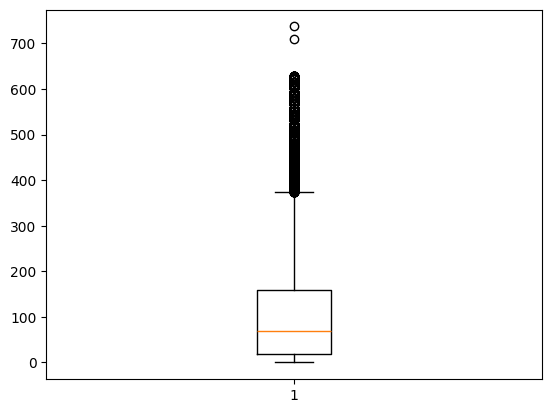

In [47]:
## Your code here
plt.boxplot(df.lead_time)

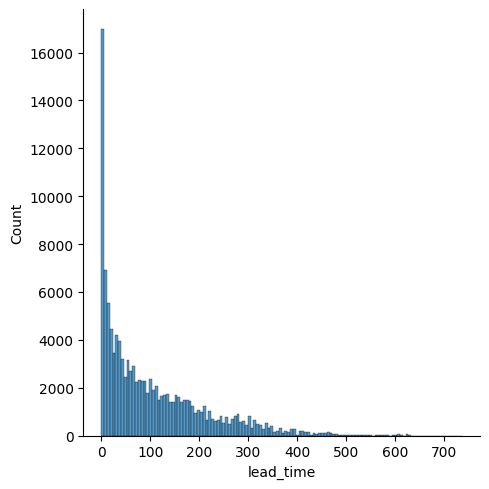

In [49]:
sns.displot(df.lead_time)

Question 3: Which one of the following transformations gives a better normality curve for lead_time?

a) Log transformation

b) Power transformation

In [51]:
## Your code here
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer()

In [65]:
df['lead_dur_pt']=pt.fit_transform(df.lead_time.values.reshape(-1,1))

In [71]:
df['lead_dur_log']=np.log1p(df.lead_time)

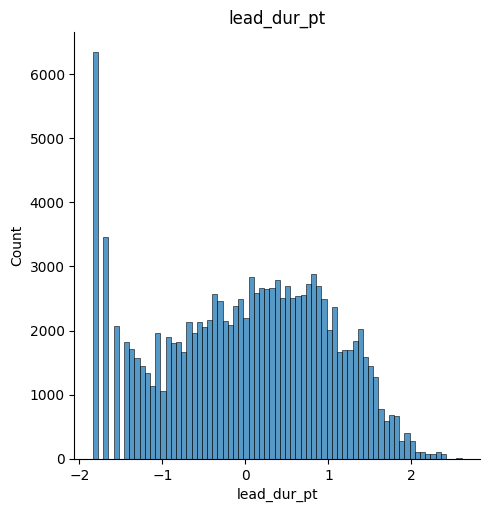

In [83]:

sns.displot(df['lead_dur_pt'])
plt.title('lead_dur_pt')

plt.show()

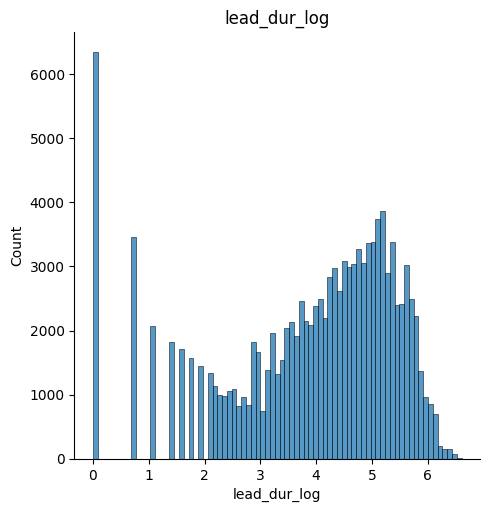

In [85]:
sns.displot(df['lead_dur_log'])
plt.title('lead_dur_log')
plt.show()

Question : What is the mean of 'adr' after standardizing it?
    
    a) 7.870703e-17
    b) -6.336417e-01
    c) 4.703527e-01
    d) 8.954200e+04

In [93]:
## Your code here
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['adr']=sc.fit_transform(df.adr.values.reshape(-1,1))
df.adr.mean()

7.617846568162561e-18

Question 5: What is the mean encoded value corresponding to 'transient' customer_type?

    a) 0.40
    b) 0.30
    c) 0.10
    d) 0.25

In [101]:
## Mean encoding
df.groupby('customer_type')['is_canceled'].mean()

customer_type
Contract           0.309617
Group              0.102253
Transient          0.407463
Transient-Party    0.254299
Name: is_canceled, dtype: float64

Question 6: What is the cardinality of the feature 'reserved_room_type'? (Note: Cardinality is the number of unique categories in a feature)

    a) 10
    b) 12
    c) 1
    d) 5

In [131]:
## Your code here
topIndexes=df.reserved_room_type.value_counts(normalize=True).sort_values(ascending=False)

In [135]:
topIndexes.cumsum()

reserved_room_type
A    0.720278
D    0.881104
E    0.935841
F    0.960106
G    0.977645
B    0.987009
C    0.994815
H    0.999849
P    0.999950
L    1.000000
Name: proportion, dtype: float64

In [123]:
df['room_type']=np.where(df.reserved_room_type.isin(topIndexes),df.reserved_room_type,'Other')

In [127]:
df.room_type.value_counts(normalize=True).cumsum()

room_type
A        0.720278
D        0.881104
E        0.935841
Other    0.975735
F        1.000000
Name: proportion, dtype: float64

Question 7: Out of the 10 reserved room types, classify the top 4 frequently reserved along with others grouped into a single category.

Which is the cumulative threshold that classifies the remaining 6 reserved room types into 'Others' category ?

    a) 93%
    b) 96%
    c) 97%
    d) 99%

In [6]:
## Your code here


Question 8: Which among the following months showed lowest cancellations?

    a) January
    b) August
    c) May
    d) December

In [139]:
## Your code here
df['month']=df.arrival_date.dt.month

In [143]:
df.groupby('month')['is_canceled'].sum().sort_values()

month
9     2676
8     2688
6     2912
11    3060
5     3138
4     3470
12    3527
3     3820
10    4145
2     4358
7     4369
1     6061
Name: is_canceled, dtype: int64